# Load in BIG_DATA2.csv

In [1]:
import csv
import pandas as pd  
import requests
# TODO FIX URL
url = "https://raw.githubusercontent.com/joseph15809/ECE143_Music_Genre_Prediction/refs/heads/main/data/BIG_DATA2.csv"
df = pd.read_csv(url, index_col=0)

# Ziyue: Display the Top 5 Genres Over Time

In [2]:
import numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

In [3]:
# --- 1. Load Data ---
url = "https://raw.githubusercontent.com/joseph15809/ECE143_Music_Genre_Prediction/refs/heads/main/data/BIG_DATA2.csv"

print(f"Reading file from URL: {url}")

try:
    df = pd.read_csv(url, index_col=0)
except Exception as e:
    print(f"Error reading the file: {e}")
    sys.exit(1)

Reading file from URL: https://raw.githubusercontent.com/joseph15809/ECE143_Music_Genre_Prediction/refs/heads/main/data/BIG_DATA2.csv


In [4]:
# --- 2. Identify Top 5 Genres Overall ---
# Calculate the overall top 5 most frequent genres
genre_counts = df['genre'].value_counts()
top_5_genres = genre_counts.head(5).index.tolist()

print("\nOverall Top 5 Genres:")
print(genre_counts.head(5).to_markdown())


Overall Top 5 Genres:
| genre       |   count |
|:------------|--------:|
| Pop         |  106412 |
| Rock        |   47227 |
| R&B         |   40511 |
| Rap/Hip Hop |   35221 |
| Country     |   32739 |


In [5]:
# --- 3. Data Preparation for Time Series ---
# A. Convert 'date' to datetime and extract year

df.reset_index(inplace=True)

df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year

# B. Filter data for the requested years (1958 to 2021)
df_filtered = df[(df['year'] >= 1958) & (df['year'] <= 2021)].copy()

# C. Filter to include only the top 5 genres
df_top5 = df_filtered[df_filtered['genre'].isin(top_5_genres)]

# D. Group by year and genre to get the count of chart appearances
genre_evolution = df_top5.groupby(['year', 'genre']).size().reset_index(name='count')

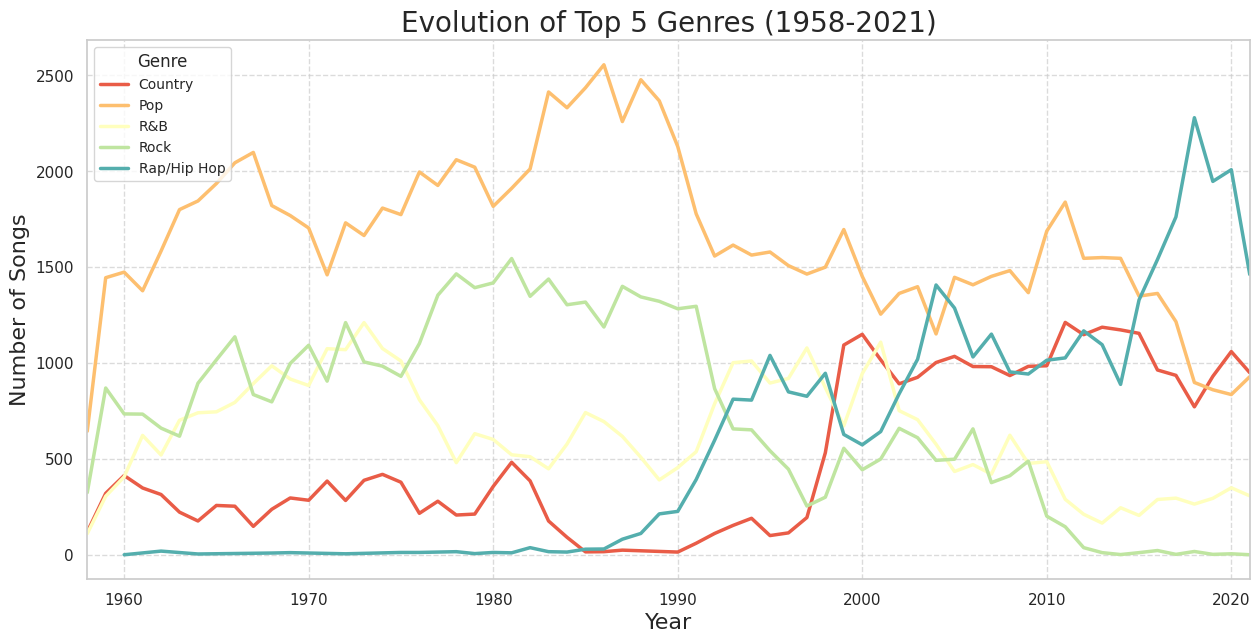

In [6]:
# --- 4. Visualization ---
sns.set_theme(style='whitegrid')

plt.figure(figsize=(15, 7))

# Create the line plot
sns.lineplot(
    data=genre_evolution, 
    x='year', 
    y='count', 
    hue='genre', 
    linewidth=2.5, 
    palette='Spectral',
)

# Set English titles and labels
plt.title('Evolution of Top 5 Genres (1958-2021)', fontsize=20)
plt.xlabel('Year', fontsize=16)
plt.ylabel('Number of Songs', fontsize=16)
plt.legend(title='Genre', title_fontsize='12', fontsize='10', loc='upper left')

# Set explicit X-axis limits and ticks for clarity
plt.xlim(1958, 2021)

# Add grid lines
plt.grid(True, linestyle='--', alpha=0.7)

# Save the chart
output_image_name = 'top_5_genres_visualization.png'
plt.savefig(output_image_name, dpi=300, bbox_inches='tight')
plt.show()

# Namisha: Top 7 Genres Over Time and Missing Genres Over Time

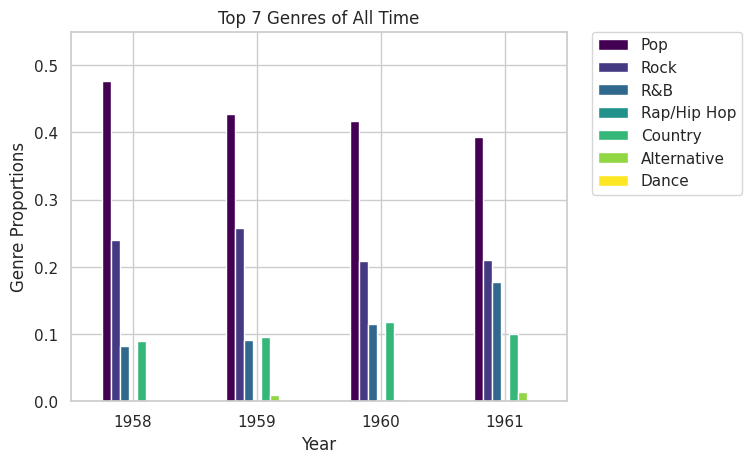

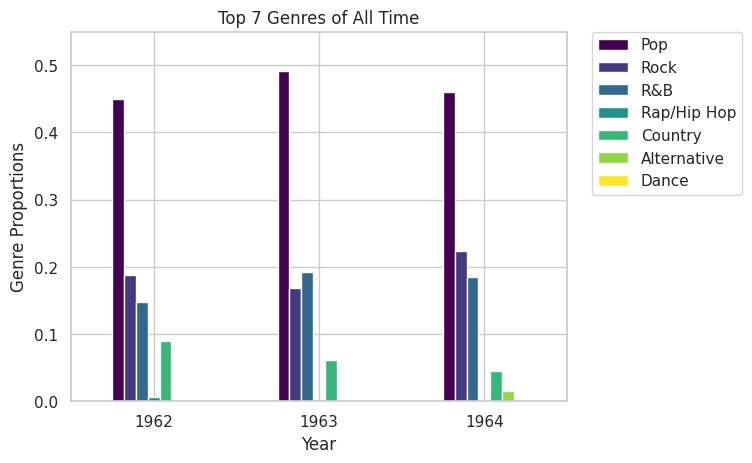

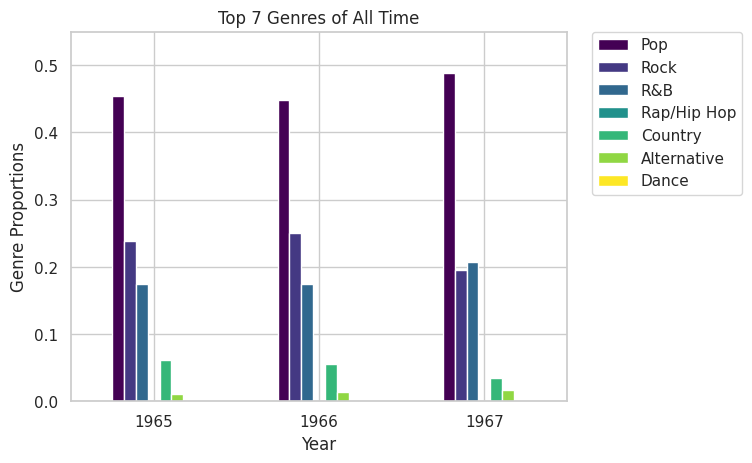

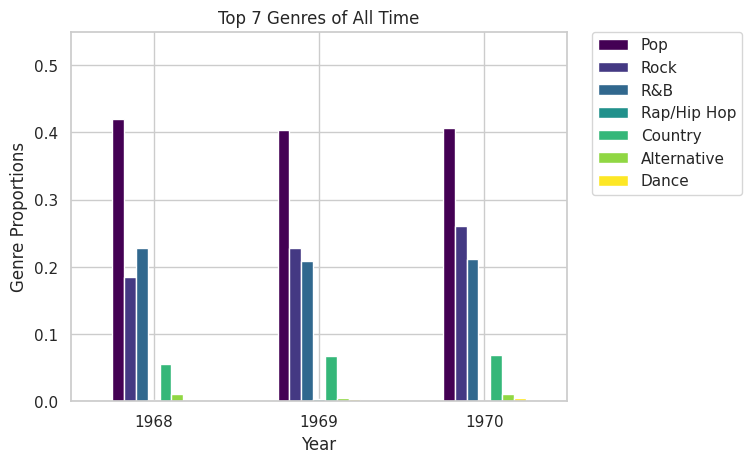

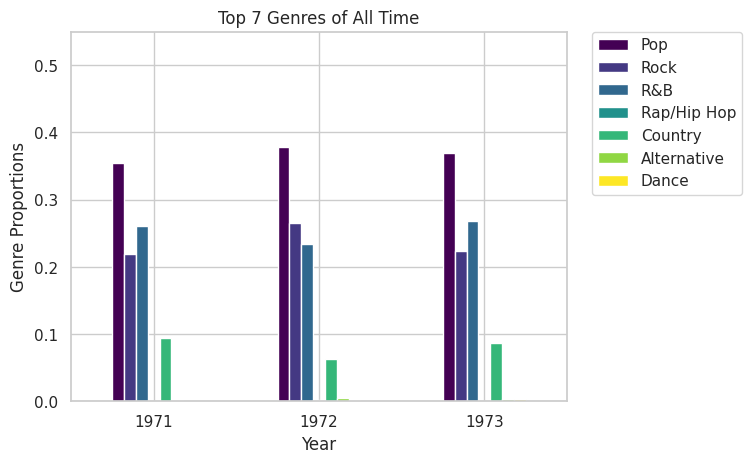

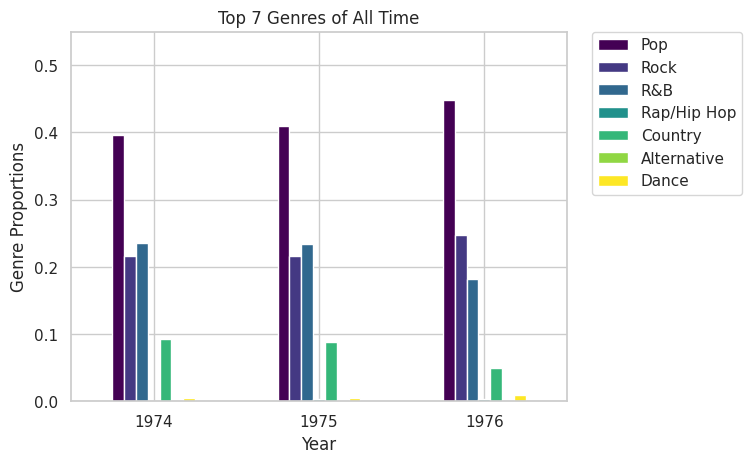

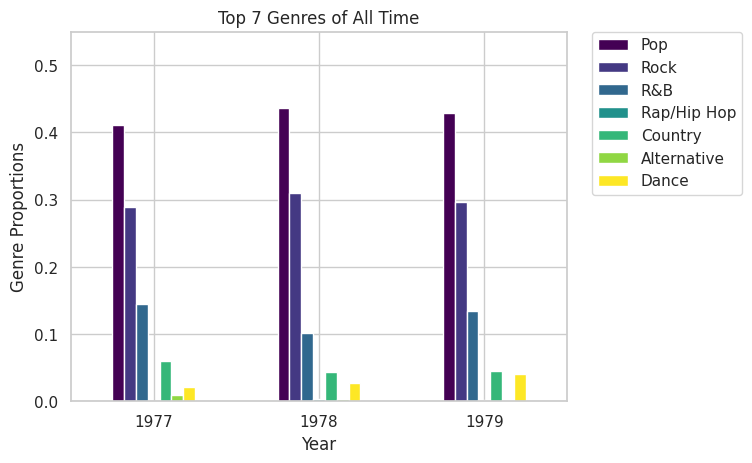

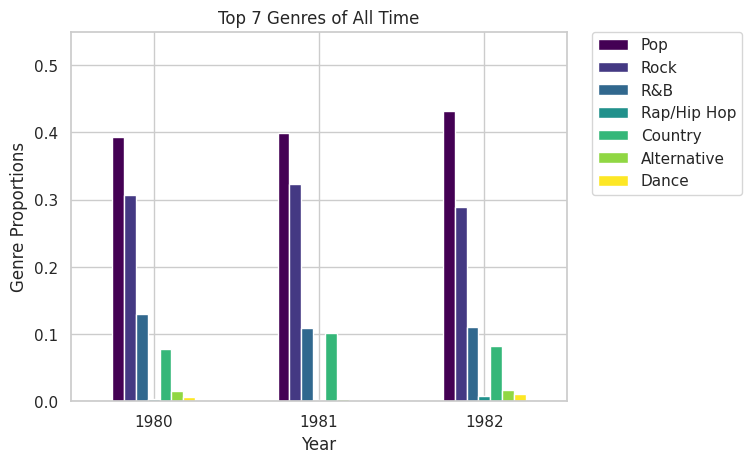

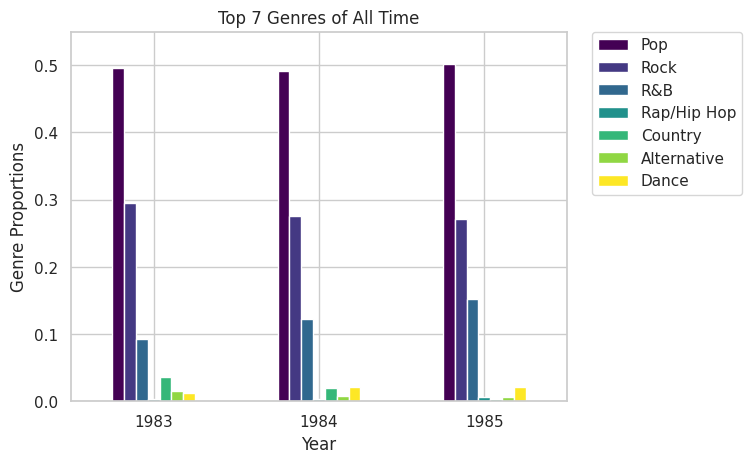

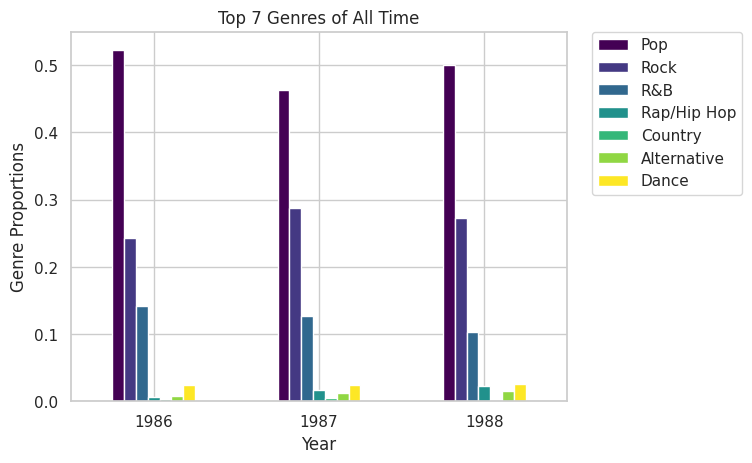

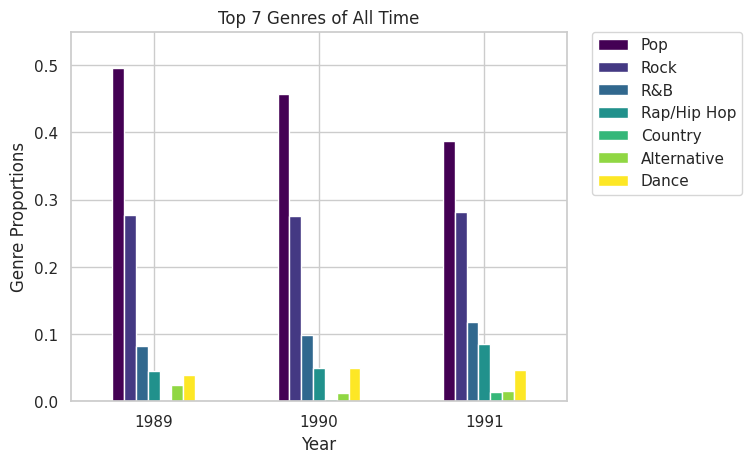

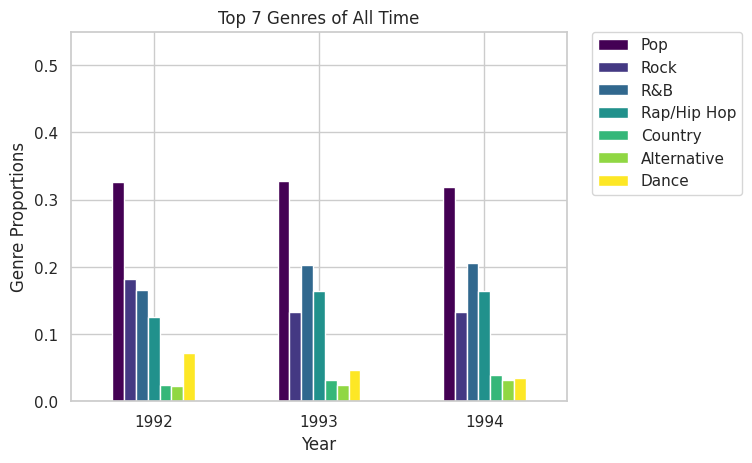

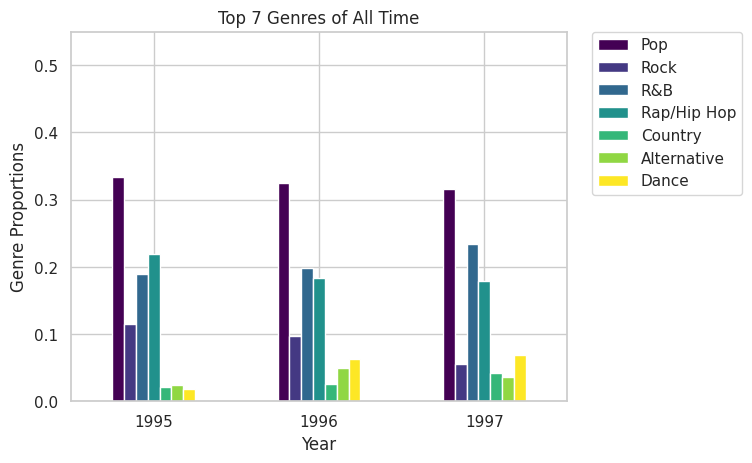

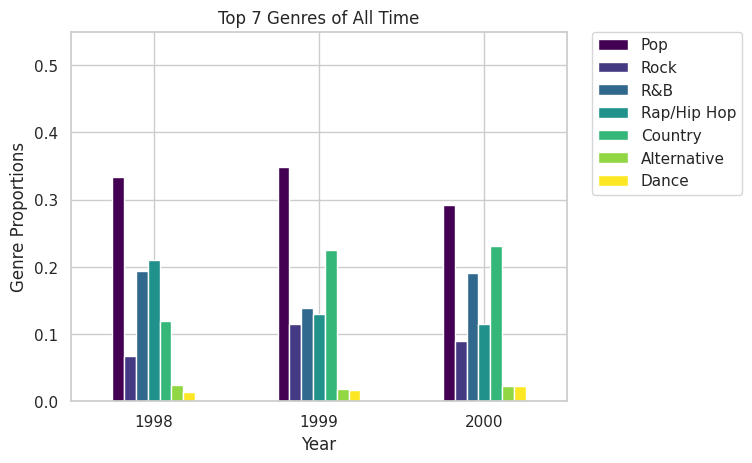

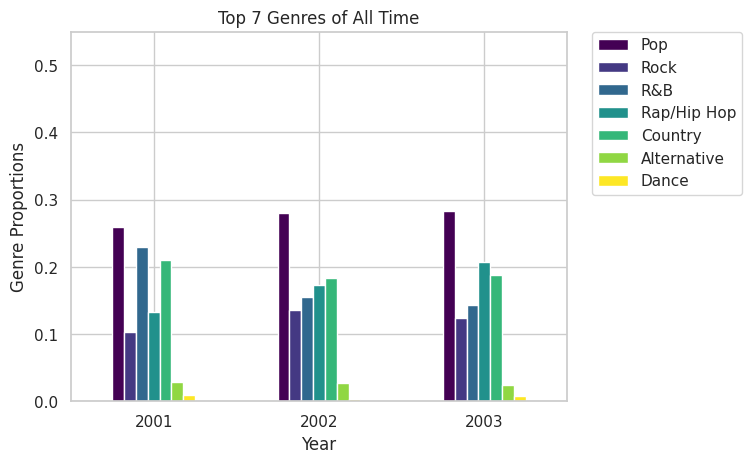

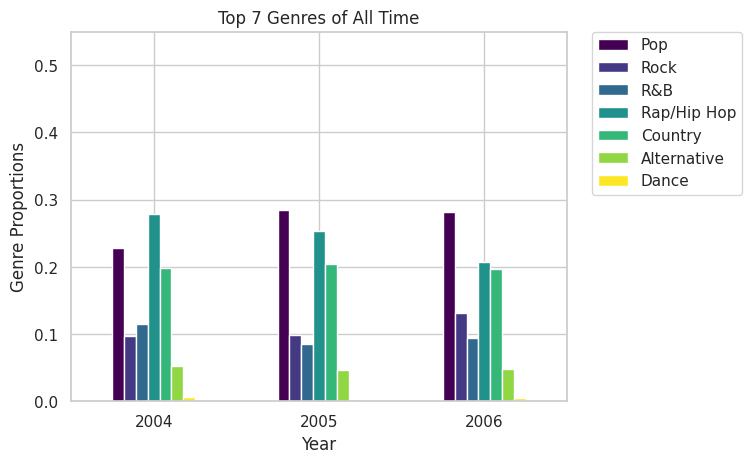

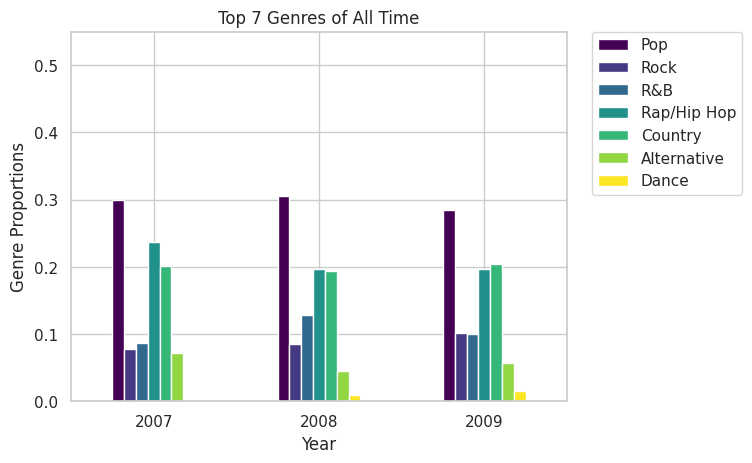

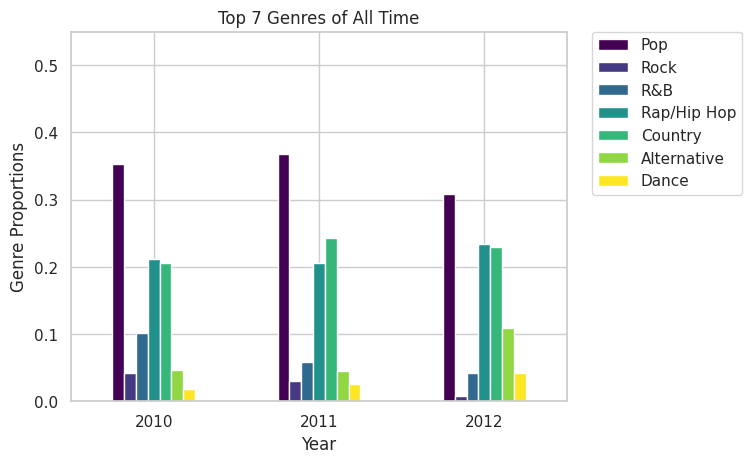

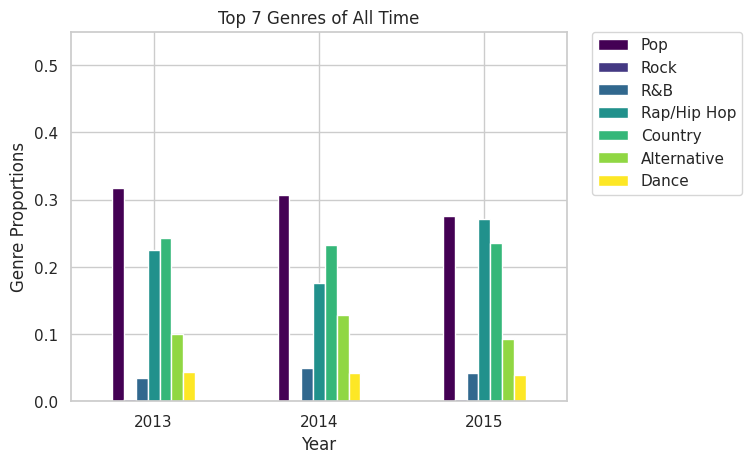

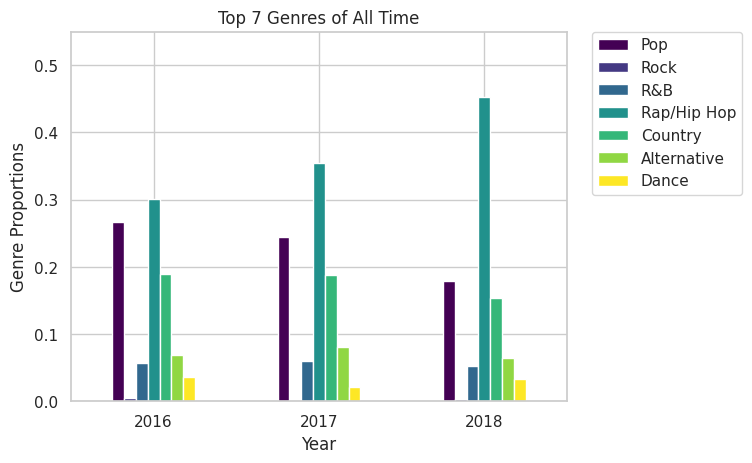

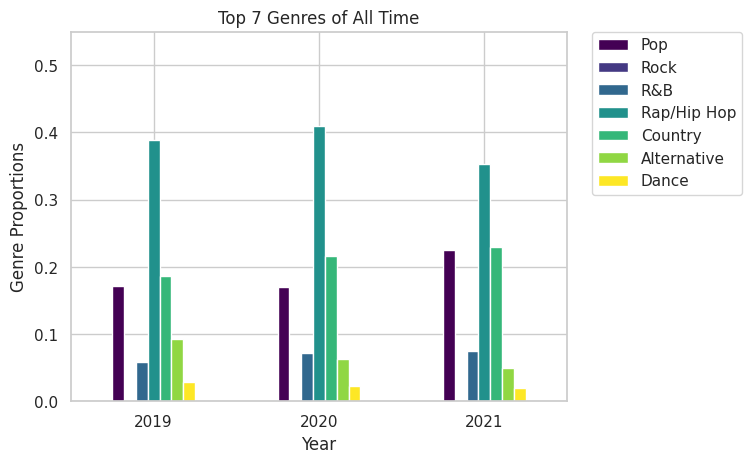

In [7]:
import pandas as pd
import matplotlib.pyplot as plot
import requests


url="https://raw.githubusercontent.com/joseph15809/ECE143_Music_Genre_Prediction/refs/heads/main/data/BIG_DATA2.csv"
resp=requests.get(url)


# Global Variables 
#INPUT_CSV = "BIG_DATA2.csv" # Input csv must be of format: 
AGG_PERIOD = "Y" # Aggregate period: Choose "Y" for yearly or "W" for weekly

# Asserts
# TODO assert csv columns
#assert(isinstance(INPUT_CSV, str) and ".csv" in INPUT_CSV)
assert(isinstance(AGG_PERIOD,str) and AGG_PERIOD in ["Y","W"])

# 1. Load Dataset: 
# Input columns: date,rank,song,artist,last-week,peak-rank,weeks-on-board,genre
df = pd.read_csv(url)

# print("\nInitial dataframe\n", df) # print initial df

# Parse date as datetime (if not already), coerce data parsing errors
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d',errors='coerce') 
df = df.dropna(subset=['date'])  # Drop rows that can't be parsed/with null values in date

# 2. Clean data:
df = df.dropna(subset=['genre']) # Remove rows missing genres 
# Normalization of genres names if needed here (rnb = r&b = R&B) TODO
#print("\nAfter dropping missing genres:\n",df) 

# 3. Choose aggregation type, yearly or weekly TODO
if(AGG_PERIOD == 'Y'):
    df['period'] = df['date'].dt.to_period('Y').dt.to_timestamp().dt.year # Use Jan 1 YYYY as index
elif(AGG_PERIOD == 'W'):
    # Use ISO Calendar numbering (ex: 2005-01-01	ISO:2004-W53-6) TODO
    iso = df['date'].dt.isocalendar() # returns df week, year, day
    df['period'] = iso['year'].astype(str) + "-W" +iso['week'].astype(str).str.zfill(2)
else:
    raise ValueError("Invalid AGG_PERIOD, must choose 'Y' or 'W'")

# 4. Build new df: proportion table
# Group by period and genre, count how many songs in each period per genre
# essentially asks: how many pop songs were on the chart during this period? how about rap? how aout pop in the next period? etc

genre_counts = df.groupby(['period','genre']).size().reset_index(name='count')
genre_counts['total-in-period'] = genre_counts.groupby('period')['count'].transform('sum')
genre_counts['proportion'] = genre_counts['count'] / genre_counts['total-in-period']
# Now genre_counts looks like form:
# period   genre	count total-in-period proportion
# 2000-W03	pop 	3     100              3/100
# 2010    	r&b 	120   5200            120/5200
proportion_table = genre_counts.pivot(index='period', columns='genre', values='proportion').fillna(0) 
# Make pivot table form:a
# period   pop   rap  ...
# 2000-W03  0.03 0.02
# Remove text after the first space
##############################
# Calculate column sums and sort the column names by these sums in descending order
sorted_columns = proportion_table.sum().sort_values(ascending=False).index

# Reindex the DataFrame with the sorted column names
df_sorted = proportion_table[sorted_columns]
top=7
keep=df_sorted.iloc[:,:top]

########################################
proportion_table.to_csv('props.csv', index=False)
keep.to_csv('props_sortedkeep.csv', index=False)

col_min=0
col_max=0
for col_max in range(4,65,3):
    prop_slice=keep.iloc[col_min:col_max]
    
    prop_slice.plot(kind='bar', colormap='viridis', rot=0)
    plot.title(f'Top {top} Genres of All Time')
    plot.xlabel('Year')
    plot.ylabel('Genre Proportions')
    plot.ylim(0, 0.55)
    plot.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plot.show()
    col_min=col_max

# Display Missing Genre Tags Over Time

(1958.0, 2021.0)

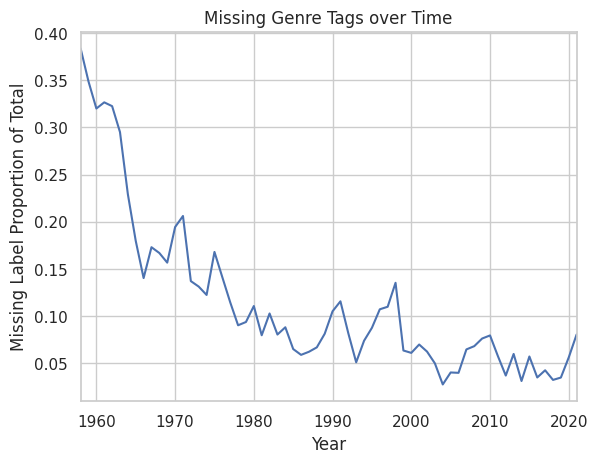

In [8]:
import pandas as pd
import matplotlib.pyplot as plot
import requests


url="https://raw.githubusercontent.com/joseph15809/ECE143_Music_Genre_Prediction/refs/heads/main/data/BIG_DATA2.csv"
resp=requests.get(url)


# Global Variables 
#INPUT_CSV = "BIG_DATA2.csv" # Input csv must be of format: 
AGG_PERIOD = "Y" # Aggregate period: Choose "Y" for yearly or "W" for weekly

# Asserts
# TODO assert csv columns
#assert(isinstance(INPUT_CSV, str) and ".csv" in INPUT_CSV)
assert(isinstance(AGG_PERIOD,str) and AGG_PERIOD in ["Y","W"])

# 1. Load Dataset: 
# Input columns: date,rank,song,artist,last-week,peak-rank,weeks-on-board,genre
df = pd.read_csv(url)

# print("\nInitial dataframe\n", df) # print initial df

# Parse date as datetime (if not already), coerce data parsing errors
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d',errors='coerce') 
df = df.dropna(subset=['date'])  # Drop rows that can't be parsed/with null values in date

# 2. Clean data:
df = df.fillna('Unknown')
# df = df.dropna(subset=['genre']) # Remove rows missing genres 
# Normalization of genres names if needed here (rnb = r&b = R&B) TODO
#print("\nAfter dropping missing genres:\n",df) 

# 3. Choose aggregation type, yearly or weekly TODO
if(AGG_PERIOD == 'Y'):
    df['period'] = df['date'].dt.to_period('Y').dt.to_timestamp().dt.year # Use Jan 1 YYYY as index
elif(AGG_PERIOD == 'W'):
    # Use ISO Calendar numbering (ex: 2005-01-01	ISO:2004-W53-6) TODO
    iso = df['date'].dt.isocalendar() # returns df week, year, day
    df['period'] = iso['year'].astype(str) + "-W" +iso['week'].astype(str).str.zfill(2)
else:
    raise ValueError("Invalid AGG_PERIOD, must choose 'Y' or 'W'")

# 4. Build new df: proportion table
# Group by period and genre, count how many songs in each period per genre
# essentially asks: how many pop songs were on the chart during this period? how about rap? how aout pop in the next period? etc

genre_counts = df.groupby(['period','genre']).size().reset_index(name='count')
genre_counts['total-in-period'] = genre_counts.groupby('period')['count'].transform('sum')
genre_counts['proportion'] = genre_counts['count'] / genre_counts['total-in-period']
# Now genre_counts looks like form:
# period   genre	count total-in-period proportion
# 2000-W03	pop 	3     100              3/100
# 2010    	r&b 	120   5200            120/5200
proportion_table = genre_counts.pivot(index='period', columns='genre', values='proportion').fillna(0) 
# Make pivot table form:a
# period   pop   rap  ...
# 2000-W03  0.03 0.02
# Remove text after the first space
##############################
# Calculate column sums and sort the column names by these sums in descending order
sorted_columns = proportion_table.sum().sort_values(ascending=False).index

# Reindex the DataFrame with the sorted column names
df_sorted = proportion_table[sorted_columns]

df_filtered = df_sorted['Unknown']


########################################
df_filtered.to_csv('unknown.csv',index=True)
df_filtered.plot(x=['period'],y=['Unknown'])
plot.title('Missing Genre Tags over Time')
plot.xlabel('Year')
plot.ylabel('Missing Label Proportion of Total')
plot.grid(True)
plot.xlim(1958, 2021)

# Rachel: Display the Correlation Analysis

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

## Load in pre-processed file

In [10]:
import csv
import pandas as pd  
import requests

url = "https://raw.githubusercontent.com/joseph15809/ECE143_Music_Genre_Prediction/refs/heads/main/data/genre_proportions_by_Y_top_5BIG_DATA2.csv"
df = pd.read_csv(url, index_col=0)

In [11]:
#csv_path = "genre_proportions_by_Y_top_5_BIG_DATA2.csv"
#df = pd.read_csv(csv_path, index_col=0)
corr = df.corr()
corr

,Pop,Rock,R&B,Rap/Hip Hop,Country
Pop,1.000000,0.816063,0.264102,-0.890936,-0.740971
Rock,0.816063,1.000000,0.358507,-0.890715,-0.775491
R&B,0.264102,0.358507,1.000000,-0.508859,-0.467643
Rap/Hip Hop,-0.890936,-0.890715,-0.508859,1.000000,0.679174
Country,-0.740971,-0.775491,-0.467643,0.679174,1.000000


Generate a Clustered Heatmap of genre correlations:

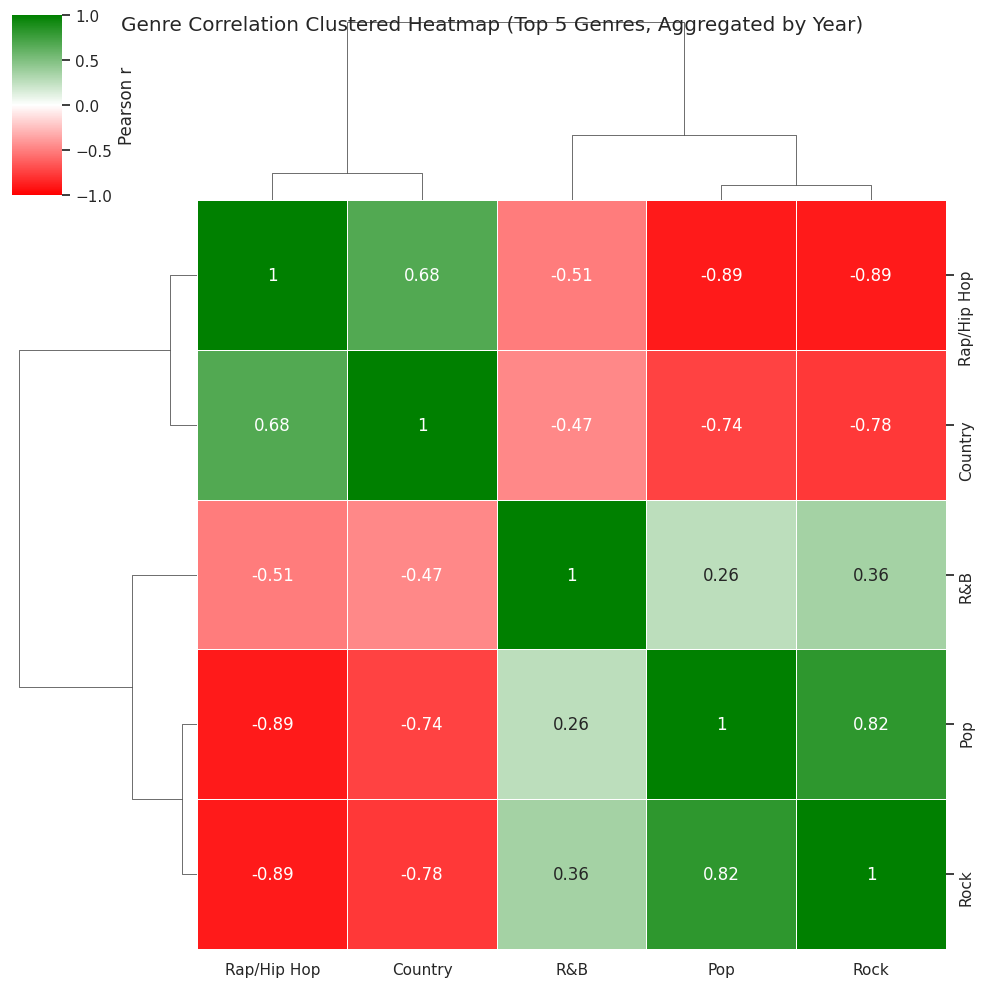

In [12]:
# 7. Visualization: Clustered Heatmap
cmap = mcolors.LinearSegmentedColormap.from_list("custom_corr", ["red","white","green"]) # custom colormap, red -1 white +0 green +1

sns.set_theme(context='notebook', style='white') # Set visual theme as notebook

cluster = sns.clustermap(data=corr, 
                         figsize=(10,10), 
                         metric='euclidean', 
                         method='average',
                         annot=True,
                         cmap=cmap,
                         vmin=-1, vmax=1,center=0, # ensure symmetry
                         cbar_kws={'label': 'Pearson r'},
                         linewidths=0.5
                        )
plt.suptitle('Genre Correlation Clustered Heatmap (Top 5 Genres, Aggregated by Year)')
plt.show()

# Shubham: Genre trend forecasting

In [13]:
# --- Setup & Imports ---
import os

# Standard data science libraries
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [14]:
# --- Validation & Evaluation ---
# Utility to split grouped (week,genre) data into train and validation windows.
def train_valid_split(grouped_df, valid_weeks=52):
    """Split grouped DataFrame into a training portion and a validation tail.
    - grouped_df: DataFrame with a 'week' column (datetime) already present
    - valid_weeks: number of weeks to reserve for validation
    Returns: (train_df, valid_df) where valid_df contains the most recent `valid_weeks`."""
    max_week = grouped_df['week'].max()
    split_week = max_week - pd.Timedelta(weeks=valid_weeks)
    train_df = grouped_df[grouped_df['week'] <= split_week].copy()
    valid_df = grouped_df[grouped_df['week'] > split_week].copy()
    print(f"Train rows: {len(train_df)}, Valid rows: {len(valid_df)}")
    return train_df, valid_df

def series_from_weeks(weeks, values):
    ts = pd.Series(data=values, index=pd.to_datetime(weeks)).sort_index()
    full_weeks = pd.date_range(start=ts.index.min(), end=ts.index.max(), freq='W-MON')
    ts_full = ts.reindex(full_weeks).interpolate(method='linear')
    return ts_full

def plot_pred_vs_actual_all_models(ts_actual, ts_train, genre, preds_dict, target='Count', steps=None, outpath='plots', show=False, plot_val=True):
    """Plot actual validation series versus predictions for multiple models.
    - ts_actual: pandas.Series indexed by week containing actual validation values
    - ts_train: pandas.Series of training values (used to show recent history)
    - preds_dict: dict of model->predicted-array (length == steps)
    - outpath: directory where PNG will be written (created if needed)."""
    if steps is None:
        steps = len(ts_actual)

    # Use only the recent training period equal to validation length
    ts_train_recent = ts_train.tail(steps//2)

    # Combine recent training + validation
    if plot_val:
        full_index = ts_train_recent.index.append(ts_actual.index)
        combined_values = np.concatenate([ts_train_recent.values, ts_actual.values])
    else:
        full_index = ts_train_recent.index
        combined_values = ts_train_recent.values

    plt.figure(figsize=(10,5))
    
    # Plot combined line for context
    plt.plot(full_index, combined_values, marker='o', color='black', label="Train + Actual")

    # Add vertical line separating train from validation
    plt.axvline(x=ts_actual.index[0], color='red', linestyle='--', label='Validation Start')
    
    # Plot model predictions aligned after training
    full_index = ts_train_recent.index.append(ts_actual.index)
    colors = ["blue", "green", "orange", "purple"]
    for i, (model, preds) in enumerate(preds_dict.items()):
        preds_full = np.concatenate([np.full(len(ts_train_recent), np.nan), preds])
        plt.plot(full_index, preds_full, marker='x', color=colors[i], label=f"Predicted {model}")

    plt.title(f"{genre} - {target} | Actual vs Predicted (All Models)")
    plt.xlabel("Week")
    plt.ylabel(target)
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()

    plt.show()
    

# Load data and prepare for plotting

In [15]:
# Load data and prepare for plotting
forecast_weeks = 20
validation_weeks = 52

url = "https://raw.githubusercontent.com/joseph15809/ECE143_Music_Genre_Prediction/refs/heads/main/data/prediction_dataset.csv"
grouped = pd.read_csv(url)

url = "https://raw.githubusercontent.com/joseph15809/ECE143_Music_Genre_Prediction/refs/heads/main/data/prediction_evaluation.csv"
df = pd.read_csv(url, parse_dates=["week"])

# Plot predictions vs actuals for all models


/tmp/ipykernel_12645/2004588300.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df["week"] = pd.to_datetime(genre_df["week"], errors="coerce")


Train rows: 3249, Valid rows: 52


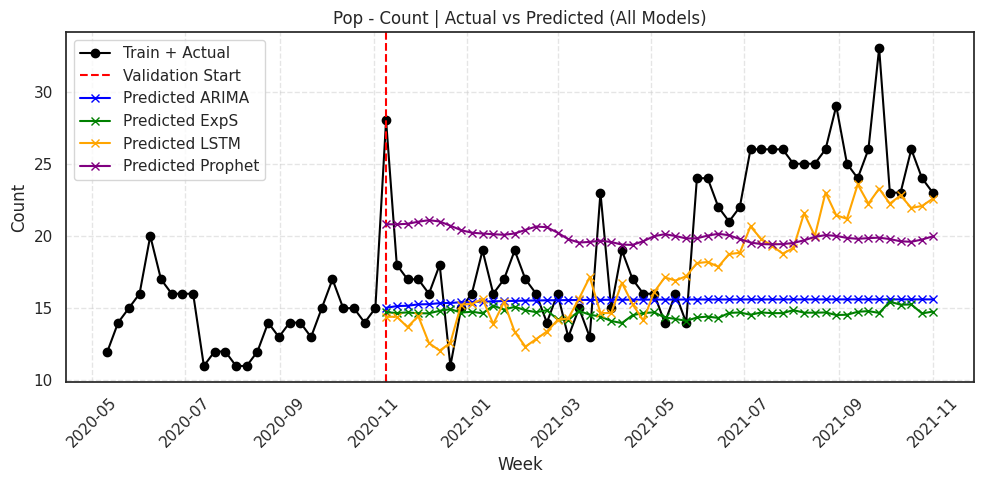

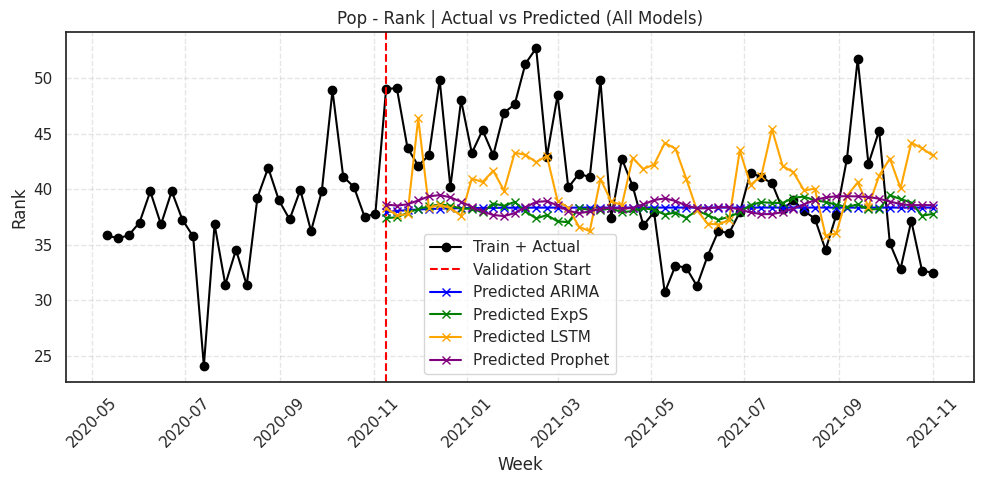

/tmp/ipykernel_12645/2004588300.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genre_df["week"] = pd.to_datetime(genre_df["week"], errors="coerce")


Train rows: 3165, Valid rows: 52


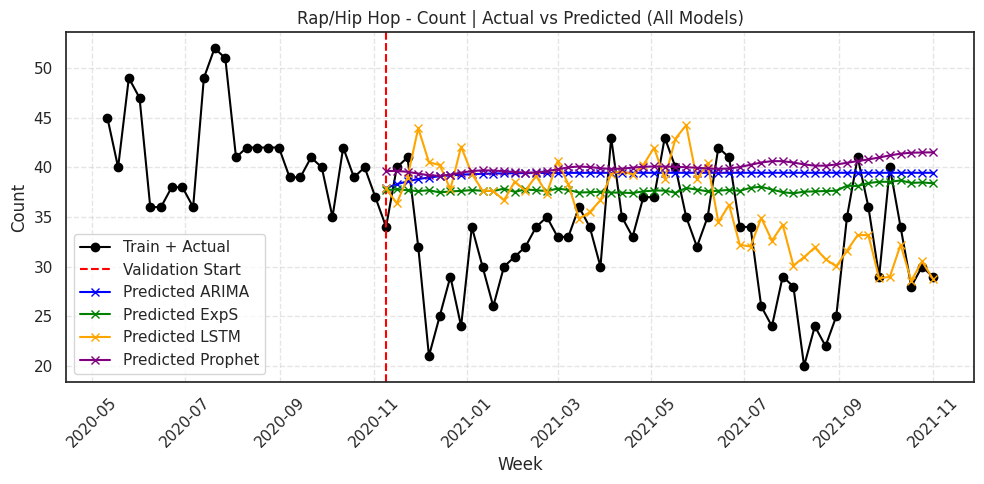

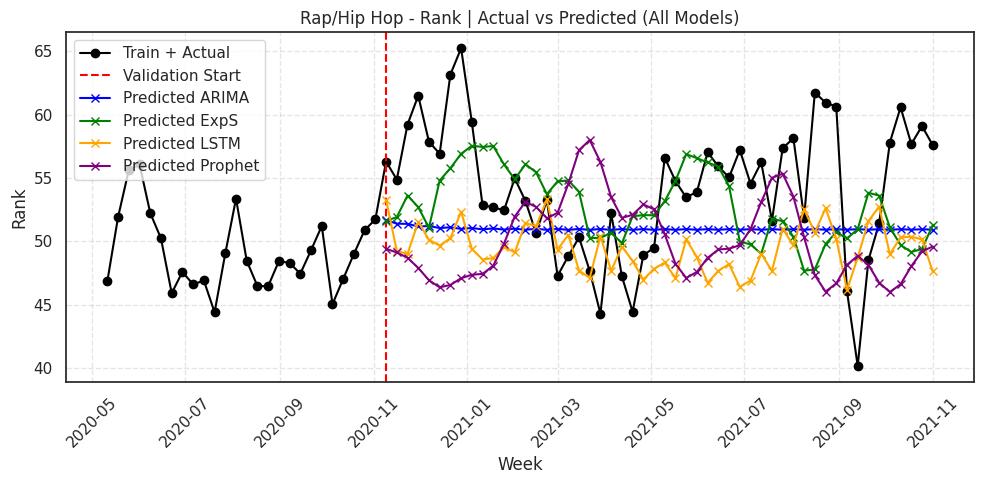

In [16]:
# Plot predictions vs actuals for all models
# for Hip Hop and Pop genres
genres = ['Pop', 'Rap/Hip Hop']

for genre in genres:
    genre_df = grouped[grouped["genre"]==genre]
    genre_df["week"] = pd.to_datetime(genre_df["week"], errors="coerce")
    genre_df = genre_df.dropna(subset=["week"])   # remove invalid weeks

    # Reindex and fill missing rows
    all_weeks = pd.date_range(
        start=genre_df["week"].min(),
        end=genre_df["week"].max(),
        freq="W-MON"
    )
    genre_df = genre_df.set_index("week").reindex(all_weeks)
    genre_df["genre"] = genre
    genre_df = genre_df.fillna(0)
    genre_df = genre_df.reset_index().rename(columns={"index":"week"})
    feature_list = genre_df.columns.difference(['week', 'genre']).tolist()
    
    tr, va = train_valid_split(genre_df, valid_weeks=validation_weeks)

    sub = df[df["genre"] == genre].sort_values("week")

    # Extract actual validation series as pandas Series
    ts_valid_count = pd.Series(sub["actual_count"].values, index=sub["week"])
    ts_valid_rank  = pd.Series(sub["actual_rank"].values, index=sub["week"])

    # Extract all models automatically
    model_names = sorted([col.replace("_pred_count", "")
                          for col in sub.columns
                          if col.endswith("_pred_count")])

    # Build prediction dictionaries for Count and Rank
    preds_count_dict = {
        model: sub[f"{model}_pred_count"].values
        for model in model_names
    }
    preds_rank_dict = {
        model: sub[f"{model}_pred_rank"].values
        for model in model_names
    }

    steps = len(sub)

    # Plot
    plot_pred_vs_actual_all_models(ts_valid_count, series_from_weeks(tr["week"].values, tr["count"].values), genre, preds_count_dict, target="Count", steps=steps, outpath=None)
    plot_pred_vs_actual_all_models(ts_valid_rank, series_from_weeks(tr["week"].values, tr["avg_rank"].values), genre, preds_rank_dict, target="Rank", steps=steps, outpath=None)

### Plot the RMSE comparing all model

/tmp/ipykernel_12645/787612003.py:27: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=rmse_long, x="genre", y="RMSE", hue="Model", ci=None)


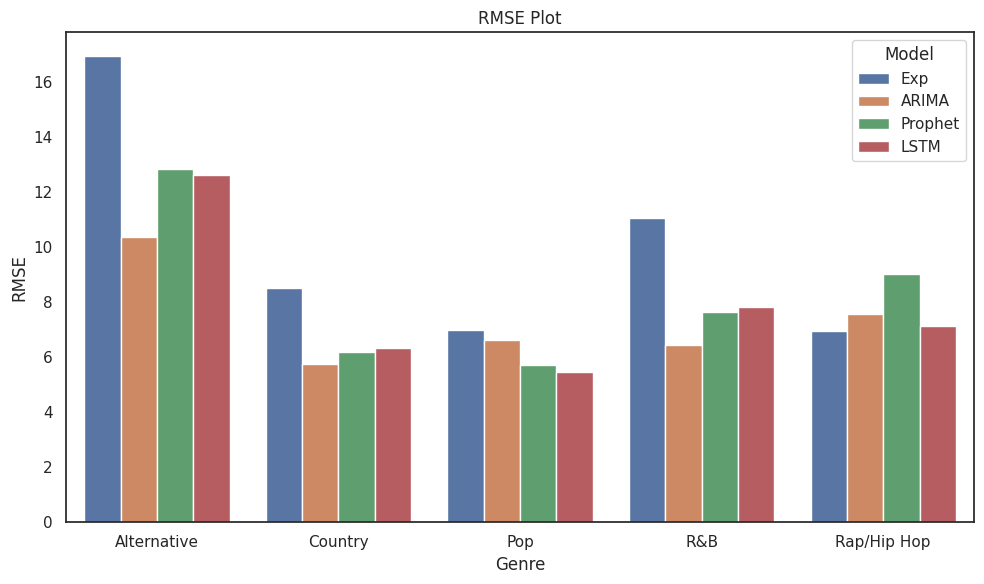

In [17]:
# --- RMSE Bar Plot ---
url = "https://raw.githubusercontent.com/joseph15809/ECE143_Music_Genre_Prediction/refs/heads/main/data/evaluate_summary.csv"
metrics_df = pd.read_csv(url)

columns = ['genre']+[col for col in metrics_df.columns if 'RMSE' in col]
metrics_df = metrics_df[columns]

models = ["Exp", "ARIMA", "Prophet", "LSTM"]
# Prepare Count RMSE
count_rmse = metrics_df[["genre"] + [m+"_RMSE_Count" for m in models]].melt(id_vars="genre", 
                                                                         var_name="Model", 
                                                                         value_name="RMSE")
count_rmse["Target"] = "Count"
count_rmse["Model"] = count_rmse["Model"].str.replace("_RMSE_Count","")

# Prepare Rank RMSE
rank_rmse = metrics_df[["genre"] + [m+"_RMSE_Rank" for m in models]].melt(id_vars="genre", 
                                                                         var_name="Model", 
                                                                         value_name="RMSE")
rank_rmse["Target"] = "Rank"
rank_rmse["Model"] = rank_rmse["Model"].str.replace("_RMSE_Rank","")

# Combine
rmse_long = pd.concat([count_rmse, rank_rmse], ignore_index=True)

plt.figure(figsize=(10,6))
sns.barplot(data=rmse_long, x="genre", y="RMSE", hue="Model", ci=None)
plt.title("RMSE Plot")
plt.ylabel("RMSE")
plt.xlabel("Genre")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

### Plot the forecasting results for all genres

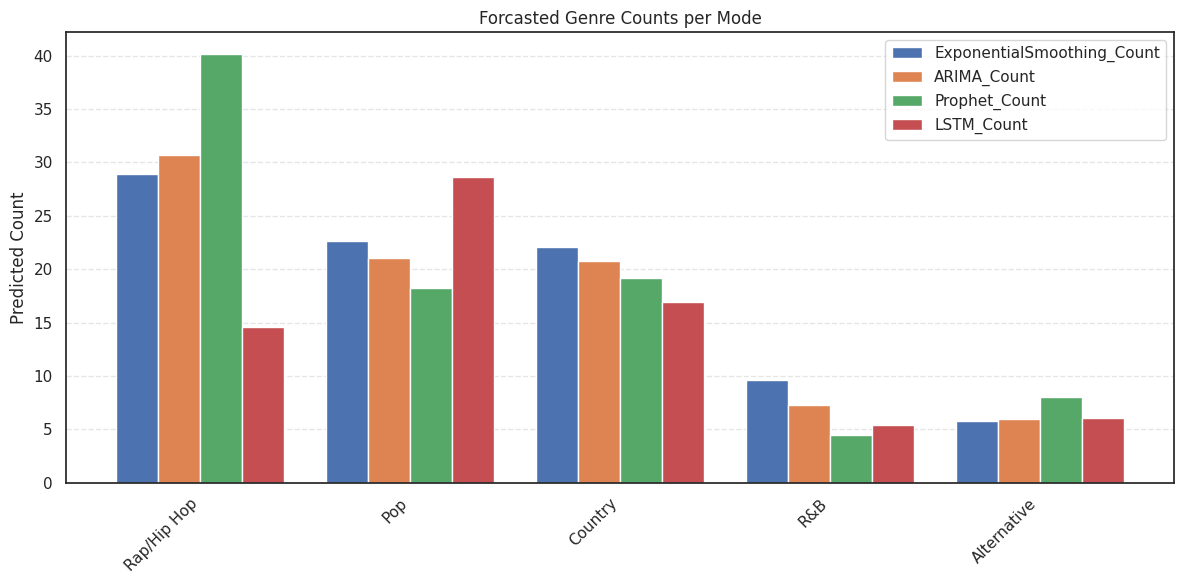

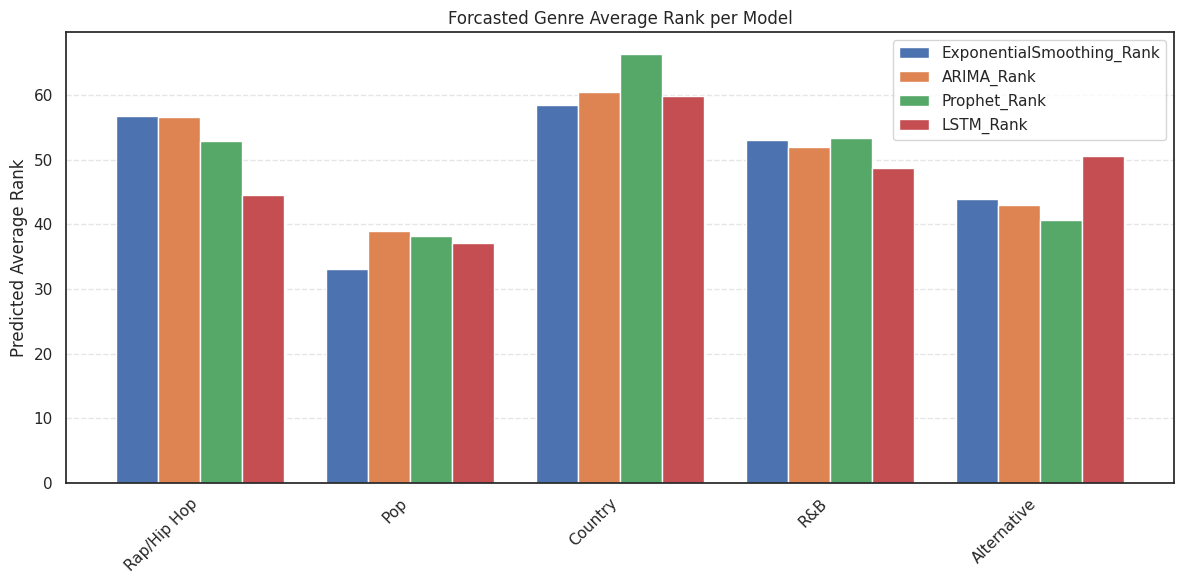

In [18]:
# Load final forecast summary
url = "https://raw.githubusercontent.com/joseph15809/ECE143_Music_Genre_Prediction/refs/heads/main/data/final_forecasts_summary.csv"
pred_df = pd.read_csv(url)
outpath="plots/trend_per_model_bar.png"

genres = pred_df["Genre"].tolist()  
n_genres = len(genres)  
x = np.arange(n_genres)  # label locations  
width = 0.2  # bar width  

# Count plot  
models_count = ["ExponentialSmoothing_Count","ARIMA_Count","Prophet_Count","LSTM_Count"]  
plt.figure(figsize=(12,6))  
for i, model in enumerate(models_count):  
    plt.bar(x + i*width, pred_df[model], width, label=model)  

plt.xticks(x + width*1.5, genres, rotation=45, ha="right")  
plt.ylabel("Predicted Count")  
plt.title("Forcasted Genre Counts per Mode")  
plt.legend()  
plt.grid(True, linestyle='--', alpha=0.5, axis='y')  
plt.tight_layout()  
plt.show()  
plt.close()  

# Rank plot  
models_rank = ["ExponentialSmoothing_Rank","ARIMA_Rank","Prophet_Rank","LSTM_Rank"]  
plt.figure(figsize=(12,6))  
for i, model in enumerate(models_rank):  
    plt.bar(x + i*width, pred_df[model], width, label=model)  

plt.xticks(x + width*1.5, genres, rotation=45, ha="right")  
plt.ylabel("Predicted Average Rank")  
plt.title("Forcasted Genre Average Rank per Model")  
plt.legend()  
plt.grid(True, linestyle='--', alpha=0.5, axis='y')  
plt.tight_layout()  
plt.show()  
plt.close()  